# 3. Optimize Scene with CMA-ES

In [1]:
import numpy as np

import cma
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torchvision

from maps.dataset import Dataset
from maps.parameters import ParameterSpace
from maps.optim.optimizer import SceneOptimizer
from maps.optim.evaluator import ModelEvaluator, LogSoftmaxObjective

In [2]:
object_name = 'white-shark_001'
root = '/Users/sgalella/Documents/datasets/MAPS/scenes'
path_labels = '/Users/sgalella/Documents/datasets/MAPS/labels.csv'

sigma = 0.2
seed = 1234
max_iter = 20
stop_prob = 0.9

In [3]:
dataset = Dataset(root=root)
print(dataset)

Dataset
  root:    /Users/sgalella/Documents/datasets/MAPS/scenes
  classes: 60
  scenes:  60


In [4]:
scene = dataset.get_scene(object_name)
print(scene)

Read blend: "/Users/sgalella/Documents/datasets/MAPS/scenes/white-shark/white-shark_001.blend"
Cycles set to GPU via METAL
Scene:
  blend file      : /Users/sgalella/Documents/datasets/MAPS/scenes/white-shark/white-shark_001.blend
  resolution      : 224 × 224
  renderer        : cycles
  file format     : PNG
  transforms (20) :
    - background.hue
    - background.noise
    - background.saturation
    - background.value
    - camera.azimuth
    - camera.distance
    - camera.elevation
    - camera.fstop
    - camera.roll
    - floor.alpha
    - floor.hue
    - floor.noise
    - floor.saturation
    - floor.value
    - light.azimuth
    - light.elevation
    - light.hue
    - light.power
    - light.radius
    - light.saturation


In [5]:
parameters_scene = scene.get()
print(parameters_scene)

{'background.hue': 0.0, 'background.noise': 0.0, 'background.saturation': 0.0, 'background.value': 1.0, 'camera.azimuth': 0.0, 'camera.distance': 5.0, 'camera.elevation': 0.7853981852531433, 'camera.fstop': 10.0, 'camera.roll': 0.0, 'floor.alpha': 0.0, 'floor.hue': 0.0, 'floor.noise': 0.0, 'floor.saturation': 0.0, 'floor.value': 0.800000011920929, 'light.azimuth': 0.0, 'light.elevation': 0.0, 'light.hue': 0.0, 'light.power': 1.0, 'light.radius': 0.0, 'light.saturation': 0.0}


In [6]:
dict_space = {
    'background.hue': {'range': [0, 2 * np.pi]},
    'background.noise': {'range': [0, 1]},
    'background.saturation': {'range': [0, 1]},
    'background.value': {'range': [0, 1]},
    'camera.azimuth': {'range': [0, 2 * np.pi]},
    'camera.distance': {'range': [2, 8]},
    'camera.elevation': {'range': [0, np.pi]},
}

parameter_space = ParameterSpace(dict_space)
print(parameter_space)

ParameterSpace
  Total dimension: 7
  Parameters:
    - background.hue: [0, 6.283185307179586]
    - background.noise: [0, 1]
    - background.saturation: [0, 1]
    - background.value: [0, 1]
    - camera.azimuth: [0, 6.283185307179586]
    - camera.distance: [2, 8]
    - camera.elevation: [0, 3.141592653589793]


In [7]:
df_labels = pd.read_csv(path_labels)

class_name = object_name.split('_')[0]
class_id = df_labels[df_labels['name'] == class_name]['label'].item()
print(f'{class_name} label: {class_id}')

white-shark label: 2


In [8]:
if torch.cuda.is_available():
        print(f'Using GPU: {torch.cuda.get_device_name(0)}')
        device = torch.device('cuda')
elif torch.backends.mps.is_available():
    print('Using Apple Silicon GPU')
    device = torch.device('mps')
else:
    print('Using CPU')
    device = torch.device('cpu')

Using Apple Silicon GPU


In [9]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

model = torchvision.models.resnet50(weights=weights)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [10]:
objective = LogSoftmaxObjective()

evaluator = ModelEvaluator(model, preprocess, objective, class_id, device)
scene_optimizer = SceneOptimizer(scene, parameter_space, evaluator)

In [11]:
np.random.seed(seed)

initial_parameters = parameter_space.sample()
initial_x = parameter_space.encode(initial_parameters)
bounds = parameter_space.bounds()

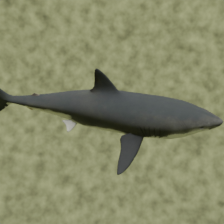

In [12]:
scene.set(initial_parameters)
scene.render()

In [13]:
opts = {'bounds': bounds, 'seed': seed}

cma_es = cma.CMAEvolutionStrategy(initial_x, sigma, opts)

(4_w,9)-aCMA-ES (mu_w=2.8,w_1=49%) in dimension 7 (seed=1234, Sun Jan 11 13:04:12 2026)


In [14]:
best, history = scene_optimizer.run(cma_es, max_iter=max_iter, stop_prob=stop_prob)

[ 1/20] Best score:  -1.337 | Best prob: 0.263 (4) | Iter. mean score:  -3.120 | Time/iter.: 7.05s
[ 2/20] Best score:  -0.717 | Best prob: 0.488 (2) | Iter. mean score:  -1.532 | Time/iter.: 6.65s
[ 3/20] Best score:  -0.717 | Best prob: 0.488 (2) | Iter. mean score:  -3.803 | Time/iter.: 6.70s
[ 4/20] Best score:  -0.717 | Best prob: 0.488 (2) | Iter. mean score:  -3.145 | Time/iter.: 6.57s
[ 5/20] Best score:  -0.717 | Best prob: 0.488 (2) | Iter. mean score:  -2.743 | Time/iter.: 6.41s
[ 6/20] Best score:  -0.643 | Best prob: 0.526 (2) | Iter. mean score:  -1.619 | Time/iter.: 6.54s
[ 7/20] Best score:  -0.635 | Best prob: 0.530 (2) | Iter. mean score:  -1.552 | Time/iter.: 6.64s
[ 8/20] Best score:  -0.602 | Best prob: 0.548 (2) | Iter. mean score:  -1.245 | Time/iter.: 7.12s
[ 9/20] Best score:  -0.591 | Best prob: 0.554 (2) | Iter. mean score:  -2.493 | Time/iter.: 6.91s
[10/20] Best score:  -0.591 | Best prob: 0.554 (2) | Iter. mean score:  -2.481 | Time/iter.: 6.74s
[11/20] Be

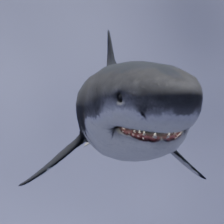

In [15]:
best_params = parameter_space.decode(best['x'])
scene.set(best_params)
scene.render()

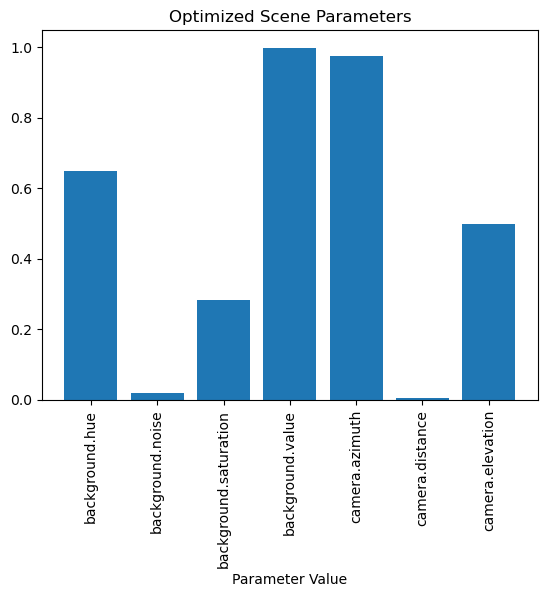

In [16]:
# Normalized parameter values [0, 1]
param_names = parameter_space.param_names
plt.bar(param_names, best['x'])
plt.xticks(rotation=90)
plt.xlabel('Parameter Value')
plt.title('Optimized Scene Parameters')
plt.show()